# Lab 3 - IT443
## Virat Shrimali - 202303061

# Image Denoising via 2D Kernel Regression

## Problem Statement

In this lab, we study how to remove noise from images using **2D Kernel Regression (Nadaraya–Watson Estimator)**.

Given:
- A clean grayscale image $ I_{true}(x, y) $

We create:
- A noisy image:
$$
I_{noisy} = I_{true} + \sigma \cdot N(0,1)
$$

Goal:
- Reconstruct a denoised image $ \hat{I}(x,y) $ using spatial smoothing.

We implement and compare three kernels:
1. Boxcar (Uniform)
2. Gaussian
3. Epanechnikov

We analyze:
- Reconstruction error (MSE)
- Perceptual quality (SSIM)
- Bias-Variance tradeoff via bandwidth $ h $

## Methodology

### 1. 2D Kernel Regression

Each pixel is reconstructed using neighboring pixels:

$$
\hat{I}(x,y) = \frac{\sum K_h(d_i) \cdot y_i}{\sum K_h(d_i)}
$$

where:
- $ d_i $ = distance from neighbor
- $ K_h(u) = K(u/h) $

---

### 2. Kernels Used

- **Boxcar**: Equal weights
- **Gaussian**: Smooth exponential decay
- **Epanechnikov**: Parabolic optimal kernel

---

### 3. Bias-Variance Tradeoff

- Small $ h $: Sharp but noisy
- Large $ h $: Smooth but blurred

---

### 4. Evaluation Metrics

- **MSE** → pixel-wise accuracy
- **SSIM** → perceptual similarity

---

### 5. Bootstrap

We resample pixel patches to estimate stability of denoising.

## Imports

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from skimage.metrics import mean_squared_error as mse
from skimage.metrics import structural_similarity as ssim

## Load and Preprocess Image

(np.float64(-0.5), np.float64(63.5), np.float64(63.5), np.float64(-0.5))

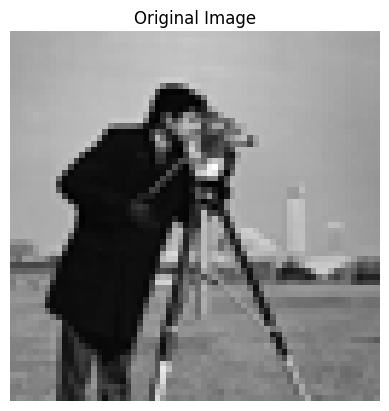

In [ ]:
# Load image
img = Image.open('/content/sample_data/cameraman.png').convert("L")
img = img.resize((64, 64))
I_true = np.array(img, dtype=np.float32)

# Normalize
I_true = I_true / 255.0

plt.imshow(I_true, cmap='gray')
plt.title("Original Image")
plt.axis('off')

## Add Noise

(np.float64(-0.5), np.float64(63.5), np.float64(63.5), np.float64(-0.5))

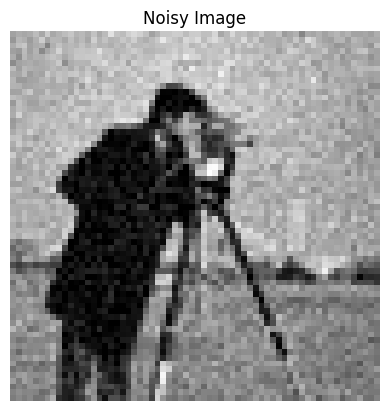

In [ ]:
sigma = 0.05
noise = sigma * np.random.randn(*I_true.shape)
I_noisy = I_true + noise
I_noisy = np.clip(I_noisy, 0, 1)

plt.imshow(I_noisy, cmap='gray')
plt.title("Noisy Image")
plt.axis('off')

## Kernel Functions

In [ ]:
def boxcar(u):
    return (u <= 1).astype(float)

def gaussian(u):
    return np.exp(-0.5 * u**2)

def epanechnikov(u):
    return np.maximum(0, 0.75 * (1 - u**2))

## 2D Kernel Regression

In [ ]:
# def kernel_regression(image, h, kernel):
#     H, W = image.shape # height and width
#     output = np.zeros_like(image) # output: new denoised image

#     for x in range(H):
#         for y in range(W):
#             weights = []
#             values = []

#             for i in range(H):
#                 for j in range(W):
#                     d = np.sqrt((x-i)**2 + (y-j)**2)
#                     u = d / h # h determines upto how much radius the neighbours should be included

#                     if u <= 1:
#                         w = kernel(u)
#                         weights.append(w)
#                         values.append(w * image[i, j])

#             weights = np.array(weights)
#             values = np.array(values)

#             if weights.sum() > 0:
#                 output[x, y] = values.sum() / weights.sum()
#             else:
#                 output[x, y] = image[x, y]

#     return output

import numpy as np

def kernel_regression(image, h, kernel):
    H, W = image.shape
    output = np.zeros_like(image)

    # Create local window grid
    r = int(np.ceil(h))
    x = np.arange(-r, r+1)
    y = np.arange(-r, r+1)
    X, Y = np.meshgrid(x, y)

    # Distance matrix (precomputed)
    D = np.sqrt(X**2 + Y**2)
    U = D / h

    # Kernel weights mask
    mask = (U <= 1)
    K = kernel(U) * mask

    for i in range(H):
        for j in range(W):

            # Extract local patch
            i_min = max(i - r, 0)
            i_max = min(i + r + 1, H)
            j_min = max(j - r, 0)
            j_max = min(j + r + 1, W)

            patch = image[i_min:i_max, j_min:j_max]

            # Corresponding kernel slice
            ki_min = r - (i - i_min)
            ki_max = r + (i_max - i)
            kj_min = r - (j - j_min)
            kj_max = r + (j_max - j)

            K_patch = K[ki_min:ki_max, kj_min:kj_max]

            # Weighted average
            weights_sum = np.sum(K_patch)

            if weights_sum > 0:
                output[i, j] = np.sum(K_patch * patch) / weights_sum
            else:
                output[i, j] = image[i, j]

    return output

## Apply Kernels

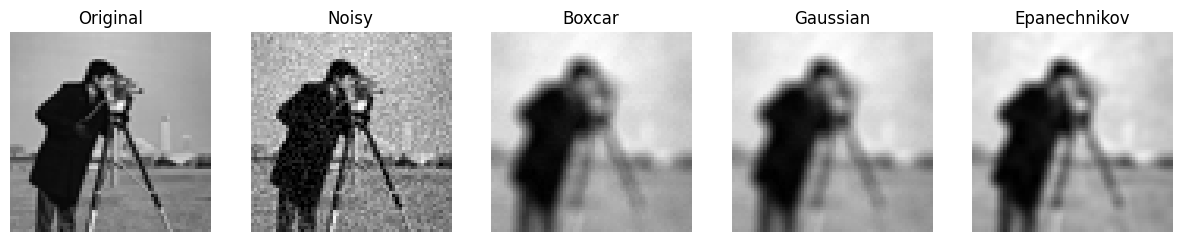

In [ ]:
h = 3

den_box = kernel_regression(I_noisy, h, boxcar)
den_gauss = kernel_regression(I_noisy, h, gaussian)
den_epan = kernel_regression(I_noisy, h, epanechnikov)

fig, ax = plt.subplots(1, 5, figsize=(15,3))

ax[0].imshow(I_true, cmap='gray'); ax[0].set_title("Original")
ax[1].imshow(I_noisy, cmap='gray'); ax[1].set_title("Noisy")
ax[2].imshow(den_box, cmap='gray'); ax[2].set_title("Boxcar")
ax[3].imshow(den_gauss, cmap='gray'); ax[3].set_title("Gaussian")
ax[4].imshow(den_epan, cmap='gray'); ax[4].set_title("Epanechnikov")

for a in ax: a.axis('off')

## Interpretation

### Boxcar (Uniform Kernel)
- Weight: $ w_i = 1 $ for $ d \le h $, else 0  
- No distance-based weighting within neighborhood  
- Hard cutoff at boundary → discontinuous kernel  
- Treats all neighbors equally regardless of proximity  

**Effect:**
- Strong averaging → removes noise aggressively  
- Sharp intensity transitions get mixed uniformly  
- Produces **piecewise constant regions (block artifacts)**  

---

### Gaussian Kernel
- Weight: \$ w_i = \exp(-\tfrac{1}{2}(d/h)^2) $
- Smooth, continuous decay with distance  
- No abrupt cutoff → gradual influence reduction  

**Effect:**
- Nearby pixels dominate, distant pixels contribute minimally  
- Produces **smooth transitions without discontinuities**  
- Preserves local coherence but introduces **progressive blurring**

---

### Epanechnikov Kernel
- Weight: $ w_i = 0.75(1 - (d/h)^2) $, for $ d \le h $  
- Compact support with quadratic decay  
- Faster drop than Gaussian near boundary  

**Effect:**
- Emphasizes local pixels strongly  
- Ignores distant pixels completely  
- Produces **sharper output than Gaussian with controlled smoothing**

---

### Edge Behavior (All Kernels)
- Weights depend only on spatial distance  
- No mechanism to detect intensity discontinuities  

**Effect:**
- Neighborhood across edges gets averaged  
- Mixing of distinct regions occurs  
- Leads to **edge blurring in all cases**

---

### Bandwidth $ h $
- Controls size of neighborhood  

**Small $ h $:**
- Limited neighbors  
- Weak smoothing  
- Noise retained  

**Large $ h $:**
- Large neighborhood  
- Strong smoothing  
- Fine details lost  

---

### Core Insight
- Output is a **weighted local average**
- Behavior fully determined by:
  - **weight decay (kernel shape)**
  - **neighborhood size (h)**

---

### Summary
- Boxcar → uniform weights → abrupt averaging → blocky  
- Gaussian → smooth decay → continuous smoothing → blur  
- Epanechnikov → compact decay → localized smoothing → sharper  

## Bootstrap

In [ ]:
def bootstrap_mse(image, noisy, kernel, h, B=50):
    H, W = image.shape
    errors = []

    pixels = noisy.flatten()

    for _ in range(B):
        sample = np.random.choice(pixels, size=len(pixels), replace=True)
        sample_img = sample.reshape(H, W)

        den = kernel_regression(sample_img, h, kernel)
        errors.append(mse(image, den))

    return errors

## Run Bootstrap

Text(0.5, 1.0, 'Bootstrap MSE Comparison')

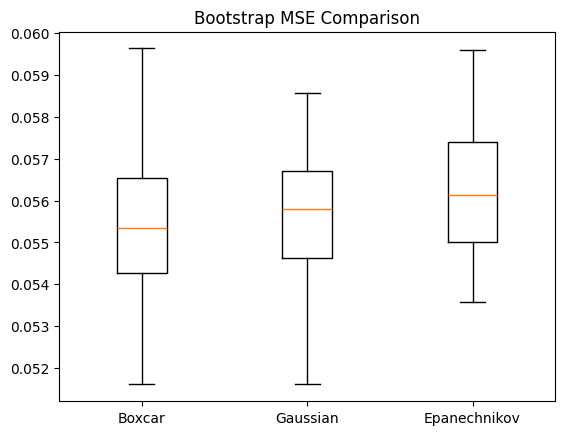

In [ ]:
err_box = bootstrap_mse(I_true, I_noisy, boxcar, 3)
err_gauss = bootstrap_mse(I_true, I_noisy, gaussian, 3)
err_epan = bootstrap_mse(I_true, I_noisy, epanechnikov, 3)

plt.boxplot([err_box, err_gauss, err_epan],
            tick_labels=["Boxcar", "Gaussian", "Epanechnikov"])
plt.title("Bootstrap MSE Comparison")

## Bootstrap MSE Interpretation

- The **median (center line)** indicates average performance:
  - Boxcar has the **lowest median MSE** → best accuracy
  - Gaussian is slightly higher
  - Epanechnikov is highest → worst among three

- The **spread (box height)** indicates stability:
  - Gaussian has the **smallest spread** → most consistent
  - Boxcar shows moderate variability
  - Epanechnikov shows higher variability

- The **overlap of boxes** indicates:
  - Differences between kernels are **not significant**

### Summary
- Boxcar → best average performance  
- Gaussian → most stable  
- Epanechnikov → slightly worse in this setup  

## Bandwidth Sweep

In [ ]:
hs = [1.0, 2.0, 3.0, 4.0, 5.0]

mse_vals = {"box":[], "gauss":[], "epan":[]}
ssim_vals = {"box":[], "gauss":[], "epan":[]}

for h in hs:
    db = kernel_regression(I_noisy, h, boxcar)
    dg = kernel_regression(I_noisy, h, gaussian)
    de = kernel_regression(I_noisy, h, epanechnikov)

    mse_vals["box"].append(mse(I_true, db))
    mse_vals["gauss"].append(mse(I_true, dg))
    mse_vals["epan"].append(mse(I_true, de))

    ssim_vals["box"].append(ssim(I_true, db, data_range=1))
    ssim_vals["gauss"].append(ssim(I_true, dg, data_range=1))
    ssim_vals["epan"].append(ssim(I_true, de, data_range=1))

## Dual Axis Plot

Text(0.5, 1.0, 'Bandwidth vs Performance')

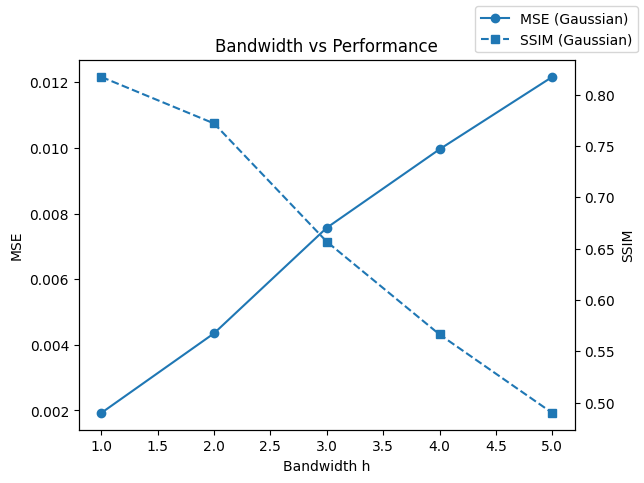

In [ ]:
fig, ax1 = plt.subplots()

ax2 = ax1.twinx()

ax1.plot(hs, mse_vals["gauss"], marker='o', label="MSE (Gaussian)")
ax2.plot(hs, ssim_vals["gauss"], marker='s', linestyle='--', label="SSIM (Gaussian)")

ax1.set_xlabel("Bandwidth h")
ax1.set_ylabel("MSE")
ax2.set_ylabel("SSIM")

fig.legend(loc="upper right")
plt.title("Bandwidth vs Performance")

## Interpretation Answers

### 1. Which kernel produces blocky or blurred artifacts? Why?
- Boxcar produces **blocky artifacts** because it assigns equal weights to all neighbors, causing sharp discontinuities.
- Large h in any kernel leads to **blurred output** due to over-smoothing.

---

### 2. Why are Gaussian/Epanechnikov better?
- They assign **higher weights to closer pixels**, preserving local structure.
- This results in smoother and more natural images compared to uniform averaging.

---

### 3. Why do kernels struggle with edges?
- At edges, neighboring pixels belong to **different intensity regions**.
- Averaging mixes these regions → causes **edge blurring**.

---

### 4. Does optimal h for MSE = optimal h for SSIM?
- No.
- MSE focuses on pixel accuracy.
- SSIM focuses on structure.
- Slight smoothing may reduce MSE but distort structure → lower SSIM.

---

### 5. Which metric is more sensitive to fine details?
- **SSIM** is more sensitive.
- It captures structural information (edges, textures), unlike MSE.

---

### 6. Bias-Variance Tradeoff
- Small h → Low bias, High variance (noisy)
- Large h → High bias, Low variance (over-smoothed)

---

### 7. Real-world (Medical Imaging)
- **SSIM should be prioritized**
- Because structural integrity (edges, shapes) is critical for diagnosis.